In [1]:
import tensorflow as tf
import cv2
import os
import matplotlib as plt
import numpy as np

In [1]:
import tensorflow as tf
print(tf.__version__)


2.18.0


In [2]:
img_array=cv2.imread("Face Expression DataSet/Data/Training/0/Training_3908.jpg")

In [3]:
img_array.shape

(48, 48, 3)

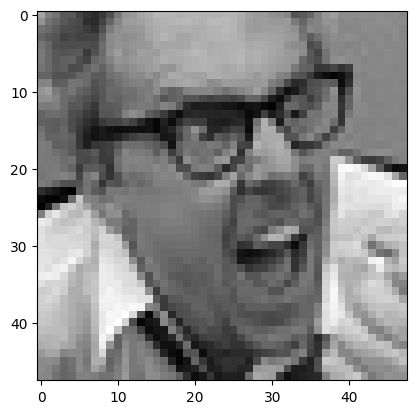

In [4]:
import matplotlib.pyplot as plt
plt.imshow(img_array)

In [5]:
Datadirectory='Face Expression DataSet/Data/Training'

In [6]:
Classes=["0","1","2","3","4","5","6"]

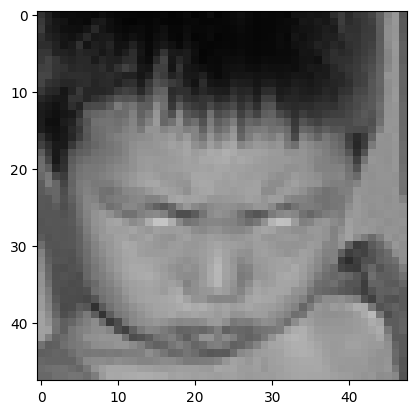

In [7]:
import cv2
for category in Classes:
    path=os.path.join(Datadirectory, category)
    for img in os.listdir(path):
        img_array=cv2.imread(os.path.join(path,img))
        plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
        plt.show()
        break
    break

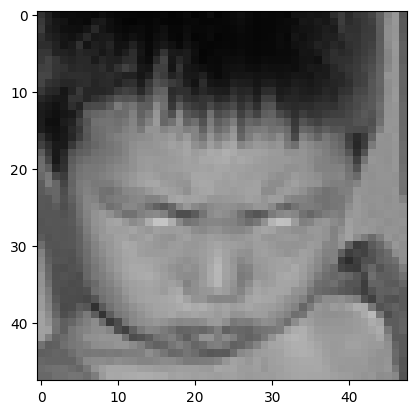

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

# Define the path where images are stored
path =os.path.join(Datadirectory, category)

for img in os.listdir(path):
    img_array = cv2.imread(os.path.join(path, img))

    # Convert BGR to RGB (Corrected function name)
    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(img_array)
    plt.show()
    
    break  # Display only the first image


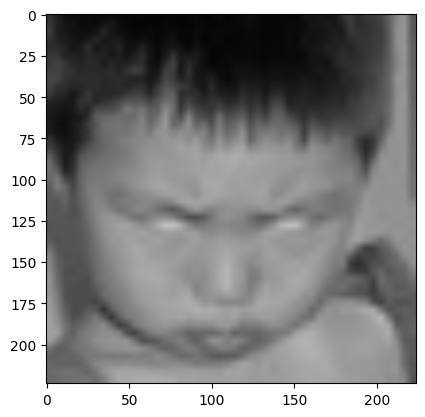

In [9]:
img_size=224
new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(cv2.cvtColor(new_array, cv2.COLOR_BGR2RGB))
plt.show()

In [10]:
new_array.shape

(224, 224, 3)

In [11]:
#read all img and convert into array
training_Data=[]
def create_training_Data():
    for category in Classes:
        path=os.path.join(Datadirectory, category)
        class_num=Classes.index(category) #labels
        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img))
                new_array=cv2.resize(img_array,(img_size,img_size))
                training_Data.append([new_array,class_num])
            except Exception as e:
                pass

In [12]:
create_training_Data()

In [13]:
print(len(training_Data))

12800


In [14]:
import random
random.shuffle(training_Data) # because it should not learn the seq.

In [15]:
X=[] # data feature
y=[] # label

for features,label in training_Data:
    X.append(features)
    y.append(label)
X=np.array(X).reshape(-1, img_size, img_size,3) #convert it to 4 deminsion 

In [16]:
X.shape

(12800, 224, 224, 3)

In [17]:
print(img_array)

[[[ 50  50  50]
  [ 32  32  32]
  [ 15  15  15]
  ...
  [133 133 133]
  [151 151 151]
  [ 86  86  86]]

 [[ 57  57  57]
  [ 34  34  34]
  [ 22  22  22]
  ...
  [138 138 138]
  [151 151 151]
  [ 89  89  89]]

 [[ 61  61  61]
  [ 30  30  30]
  [ 24  24  24]
  ...
  [142 142 142]
  [149 149 149]
  [ 89  89  89]]

 ...

 [[103 103 103]
  [100 100 100]
  [100 100 100]
  ...
  [149 149 149]
  [104 104 104]
  [ 85  85  85]]

 [[107 107 107]
  [111 111 111]
  [113 113 113]
  ...
  [151 151 151]
  [120 120 120]
  [ 86  86  86]]

 [[104 104 104]
  [104 104 104]
  [112 112 112]
  ...
  [143 143 143]
  [136 136 136]
  [ 83  83  83]]]


In [18]:
#normalize the data
X=X/255.0;

In [19]:
type(y)

list

In [20]:
Y=np.array(y)
Y.shape

(12800,)

In [21]:
#Model Tranfer Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [22]:
model=tf.keras.applications.MobileNetV2()

In [23]:
model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [24]:
#Transfer learning tuning
base_input=model.layers[1].input


In [25]:
base_input

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

In [26]:
base_output=model.layers[-2].output

In [27]:
base_output

<KerasTensor shape=(None, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_154>

In [28]:
final_output=layers.Dense(128)(base_output)
final_ouput=layers.Activation('relu')(final_output)
final_output=layers.Dense(64)(final_ouput)
final_ouput=layers.Activation('relu')(final_output)
final_output=layers.Dense(7,activation='softmax')(final_ouput)

In [29]:
final_output

<KerasTensor shape=(None, 7), dtype=float32, sparse=False, ragged=False, name=keras_tensor_160>

In [30]:
new_model=keras.Model(inputs=base_input, outputs=final_output)


In [31]:
new_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,430,663 (9.27 MB)

 Trainable params: 2,396,551 (9.14 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [32]:
new_model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [34]:
new_model.fit(X, Y, epochs=32, batch_size=16, verbose=1)

Epoch 1/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 708s 853ms/step - accuracy: 0.3893 - loss: 1.5824 
Epoch 2/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 685s 857ms/step - accuracy: 0.5067 - loss: 1.3010 
Epoch 3/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 682s 852ms/step - accuracy: 0.5440 - loss: 1.1951 
Epoch 4/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 681s 851ms/step - accuracy: 0.5781 - loss: 1.1444 
Epoch 5/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 680s 850ms/step - accuracy: 0.5912 - loss: 1.0832 
Epoch 6/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 680s 850ms/step - accuracy: 0.6108 - loss: 1.0340 
Epoch 7/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 683s 853ms/step - accuracy: 0.6385 - loss: 0.9599 
Epoch 8/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 682s 852ms/step - accuracy: 0.6672 - loss: 0.9069 
Epoch 9/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 682s 853ms/step - accuracy: 0.6895 - loss: 0.8302 
Epoch 10/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 683s 853ms/step - accuracy: 0.7126 - loss: 0.7734 
Epoch 11/32
800/800 ━━━━━━━━━━━━━━━━━━━━ 683s 854ms/step - accuracy: 0.7286 - loss: 0.713

In [35]:
new_model.save("FER13Model.h5")  # Saves as an HDF5 file


In [36]:
new_model.save("FER13Model.keras")  # Saves as an HDF5 file


In [33]:
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model("FER13Model.keras")

# Ensure training data is loaded
# X, Y = (Reload training data if lost)

# Evaluate the model
loss, accuracy = model.evaluate(X, Y)

print(f"Final Training Accuracy: {accuracy*100:.2f}%")
print(f"Final Training Loss: {loss:.4f}")


C:\Users\yashp\anaconda3\envs\FER_TL\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 164 variables whereas the saved optimizer has 326 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


400/400 ━━━━━━━━━━━━━━━━━━━━ 131s 323ms/step - accuracy: 0.7298 - loss: 1.0241
Final Training Accuracy: 73.14%
Final Training Loss: 1.0310


In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import filedialog

# Load the trained model
model = tf.keras.models.load_model("FER13Model.keras")

# Define class labels (assuming these are the correct labels)
class_labels = ["0", "1", "2", "3", "4", "5", "6"]

# Function to process and predict an image
def predict_expression():
    # Open file dialog to select an image
    file_path = filedialog.askopenfilename(filetypes=[("Face Expression DataSet/Data/testing/1/PrivateTest_807646.jpg", "*.jpg;*.jpeg;*.png")])
    
    if not file_path:
        print("No file selected.")
        return

    # Read and preprocess the image
    img = cv2.imread(file_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img_resized = cv2.resize(img, (224, 224))   # Resize to match model input size
    img_normalized = img_resized / 255.0        # Normalize pixel values
    
    # Reshape to match model input shape (1, 224, 224, 3)
    img_input = np.expand_dims(img_normalized, axis=0)

    # Make a prediction
    predictions = model.predict(img_input)
    predicted_class = np.argmax(predictions)  # Get the class index with highest probability
    predicted_label = class_labels[predicted_class]  # Get the class label

    # Display the image with predicted label
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_label}")
    plt.show()

# Run the function
predict_expression()


In [33]:
new_model=tf.keras.models.load_model('FER13Model.keras')

C:\Users\yashp\anaconda3\envs\FER_TL\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 164 variables whereas the saved optimizer has 326 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [34]:
frame=cv2.imread("Face Expression DataSet/Data/images.jpg")

In [35]:
frame.shape

(183, 275, 3)

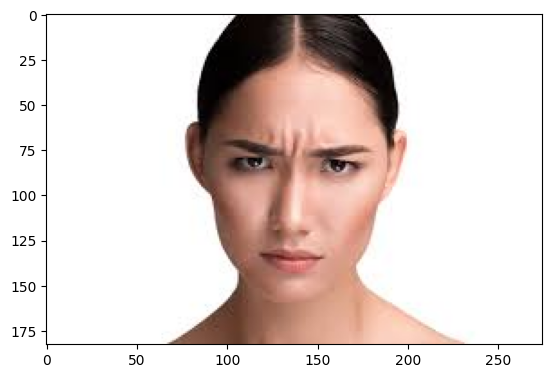

In [36]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(frame,cv2.COLOR_BGR2RGB))

In [37]:
#FACE DETECTION ALGO
faceCascade=cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [38]:
gray=cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

In [39]:
gray.shape

(183, 275)

In [41]:
faces=faceCascade.detectMultiScale(gray,1.1,4)
for x,y,w,h in faces:
    roi_gray=gray[y:y+h, x:x+w]
    roi_color=frame[y:y+h, x:x+w]
    cv2.rectangle(frame,(x,y), (x+w, y+h), (255,0,0),2)
    facess=faceCascade.detectMultiScale(roi_gray)
    if len(faces)== 0:
        print("Face not detected")
    else:
        for (ex,ey,ew,eh) in facess:
            face_roi=roi_color[ey: ey+eh, ex:ex +ew]

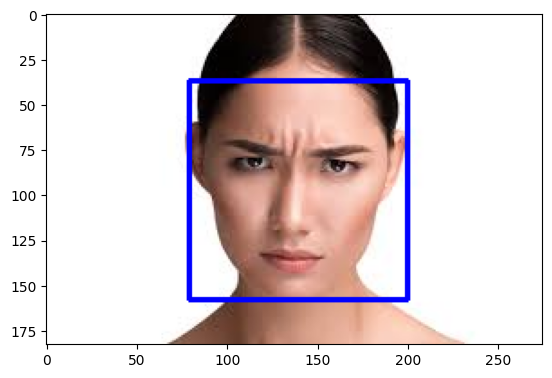

In [42]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

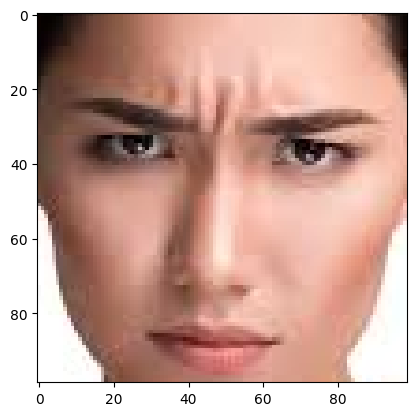

In [43]:
plt.imshow(cv2.cvtColor(face_roi, cv2.COLOR_BGR2RGB))

In [44]:
final_image=cv2.resize(face_roi,(224,224))
final_image=np.expand_dims(final_image,axis=0)
final_image=final_image/225.0

In [45]:
Predictions=new_model.predict(final_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 927ms/step


In [46]:
Predictions[0]

array([3.4199070e-02, 6.9384462e-01, 2.2766563e-01, 5.9569179e-04,
       3.9976370e-03, 3.6111649e-02, 3.5856396e-03], dtype=float32)

In [47]:
np.argmax(Predictions)

np.int64(1)

In [51]:
#REAL DEMO
import cv2
path='haarcascade_frontalface_default.xml'
font_scale=1.5
font=cv2.FONT_HERSHEY_PLAIN

rectangle_bgr=(225,225,225)
img=np.zeros((500,500))
text="Some text in a box!"
(text_width,text_height)=cv2.getTextSize(text,font,fontScale=font_scale,thickness=1)[0]
text_offset_x=10
text_offset_y=img.shape[0]-25

box_coords=((text_offset_x, text_offset_y), (text_offset_x + text_width + 2, text_offset_y-text_height-2))
cv2.rectangle(img, box_coords[0], box_coords[1], rectangle_bgr, cv2.FILLED)
cv2.putText(img,text,(text_offset_x, text_offset_y), font, fontScale=font_scale, color=(0,0,0), thickness=1)

cap=cv2.VideoCapture(1)
if not cap.isOpened():
    cap= cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open Webcam")

while True:
    ret, frame=cap.read()
    faceCascade=cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    faces=faceCascade.detectMultiScale(gray,1.1,4)
    for x,y,w,h in faces:
        roi_gray=gray[y:y+h, x:x+w]
        roi_color=frame[y:y+h, x:x+w]
        cv2.rectangle(frame,(x,y), (x+w, y+h), (255,0,0),2)
        facess=faceCascade.detectMultiScale(roi_gray)
        if len(faces)== 0:
            print("Face not detected")
        else:
            for (ex,ey,ew,eh) in facess:
                face_roi=roi_color[ey: ey+eh, ex:ex +ew]
    final_image=cv2.resize(face_roi,(224,224))
    final_image=np.expand_dims(final_image,axis=0)
    final_image=final_image/225.0

    font=cv2.FONT_HERSHEY_SIMPLEX
    Predictions=new_model.predict(final_image)

    font_scale=1.5
    font=cv2.FONT_HERSHEY_PLAIN

    if(np.argmax(Predictions)==0):
        status="Angry"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(0,0,255))

        
    elif (np.argmax(Predictions)==1):
        status="Disgust"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(0,0,255))

    elif (np.argmax(Predictions)==3):
        status="Happy"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))

    elif (np.argmax(Predictions)==4):
        status="Sad"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))


    elif (np.argmax(Predictions)==5):
        status="Suprise"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))

    else:
        status="Neural"
        x1,y1,w1,h1=0,0,175,75
        cv2.rectangle(frame,(x1,x1),(x1+w1,y1+h1),(0,0,0),-1)

        cv2.putText(frame,status,(x1+ int(w1/10),y1 +int(h1/2)), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0,255),2)
        cv2.putText(frame,status,(100,150), font, 3,(0,0,255),2,cv2.LINE_4)
        cv2.rectangle(frame,(x,y), (x+w, y+h),(255,0,0))


    cv2.imshow("Face Emotion Recogition",frame)
    
    if cv2.waitKey(2) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyALLWindows()
        
        
        

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 

In [54]:
#RUNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN
import cv2
import numpy as np
from collections import Counter
from tensorflow.keras.models import load_model

# Load the trained model
new_model = load_model("FER13Model.keras")  # Replace with your actual model path

# Load face detection model
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Initialize webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open Webcam")

# Store last few predictions for stability
prediction_history = []
history_size = 5  # Number of recent predictions to consider

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        roi_color = frame[y:y+h, x:x+w]
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

        # Resize face ROI to match model input
        final_image = cv2.resize(roi_color, (224, 224))
        final_image = np.expand_dims(final_image, axis=0) / 255.0  # Normalize

        # Make prediction
        Predictions = new_model.predict(final_image)
        prediction_history.append(np.argmax(Predictions))

        # Keep only the last `history_size` predictions
        if len(prediction_history) > history_size:
            prediction_history.pop(0)

        # Choose the most common prediction
        most_common_prediction = Counter(prediction_history).most_common(1)[0][0]
        emotion_dict = {0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy", 4: "Sad", 5: "Surprise", 6: "Neutral"}
        status = emotion_dict.get(most_common_prediction, "Unknown")

        # Display emotion label
        cv2.rectangle(frame, (0, 0), (175, 50), (0, 0, 0), -1)
        cv2.putText(frame, status, (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Show video
    cv2.imshow("Face Emotion Recognition", frame)

    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━

KeyboardInterrupt: 